In [219]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import os
import imageio

#%matplotlib qt
#%matplotlib ipympl


In [220]:
root_directory = "HippocampalMRISlices"
patient_num = 1

# Get the list patient folders
patient_folders = sorted(os.listdir(root_directory))

# Get the single patient folder you are looking for 
directory = os.path.join(root_directory, patient_folders[patient_num])

# All the dicoms for a particular folder
dicom_names = os.listdir(directory)


## Viewing a single slice

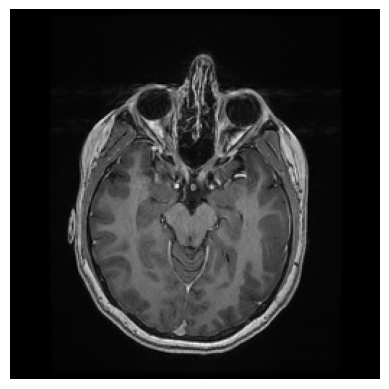

In [221]:
# choose which slice to open using index 
# and find the dicom name for that
# this is directory independent, i.e. will work for other folders too 

# Opening a single dicom 
slice_number = 4

# This find the "name" of the file, and get its full path 
dicom_name = dicom_names[slice_number]
dicom_path = os.path.join(directory, dicom_name)

# read dicom file
ds = pydicom.dcmread(dicom_path)  

# EXTRACTS THE PIXE DATA FROM THE DICOM FILE
image_data = ds.pixel_array 

plt.imshow(image_data, cmap='gray') # print pixel data of dicom file
plt.axis('off')
plt.show()
#print(ds)

## Extracting all dicoms

In [222]:
# Extract all the dicom files in the directory 
dicoms = [] 
for dicom_name in dicom_names:
    dicom_path = os.path.join(directory, dicom_name)
    ds = pydicom.dcmread(dicom_path)
    dicoms.append(ds)

In [201]:
# there are a few different types of dicoms in the directory
# and if you try to load the pixel data for all, 
# the ones without pixel data will fail
# there are a few ways to handle this 

# You can try all the files, and see which fail 
for ind in range(len(dicoms)):
    ds = dicoms[ind]  
    try:
        ds.pixel_array
    except:
        print(f"Failed for file: {dicom_names[ind]}")
        ds_type = ds.file_meta.MediaStorageSOPClassUID.name
        print(f"DS Type: {ds_type}")
        # Remove that value from the list 
        dicoms.pop(ind)
print(f"Total Slices = {len(dicoms)}")

# Or if you know the Class UID Name you are looking for, 
# you can remove unwanted ones from the loaded dicoms
for ind in range(len(dicoms)):
    ds = dicoms[ind]
    ds_type = ds.file_meta.MediaStorageSOPClassUID.name
    if ds_type != 'MR Image Storage':
        dicoms.pop(ind)
print(f"Total Slices = {len(dicoms)}")

# Both these methods should produce the same result


Failed for file: RS.1.2.246.352.221.50225536432001285041133811588211639175.dcm
DS Type: RT Structure Set Storage
Total Slices = 292
Total Slices = 292


In [ ]:
# The order these have been loaded in in not necessarily the 
# correct order so we can extract that here 

# There are a few different dicom attributes that can help us the order 
# ds.ImagePositionPatient
# ds.SliceLocation
# ds.InstanceNumber

# ImagePositionPatient[2] represents the Z-coordinate, 
#   allowing slices to be reconstructed in the correct anatomical order.
# Slice location is the same as ImagePositionPatient[2]
# Instance number is the number of the slice in the series 

# Sorting the list of slices, based on the value in slice order

#dicoms = sorted(dicoms,key=lambda x: float(x.ImagePositionPatient[2]))
dicoms = sorted(dicoms,key=lambda x: float(x.SliceLocation))
#dicoms = sorted(dicoms,key=lambda x: float(x.InstanceNumber))

# Now indexing sequentially will actually get to sequential slices

In [217]:
# extract the pixel arrays, which are now in the correct order 
slices = [ds.pixel_array for ds in dicoms]

# Convert individual 2D array into one 3D NumPy volume
volume = np.stack(slices)

# The resulting array has dimensions: (number of slices, image height, image width)
print(f"Volume dimensions: {volume.shape}")

Volume dimensions: (292, 256, 256)


## Viewing volume data

In [227]:
# For the get vol data function would be
def get_vol_data_pydicom(patient_num):
    """
    Extract a volume from a dictory with a dicom for each 
    individual slice of the 3D scan
    """    
    # Init the dicoms variable 
    dicoms = [] 

    # Set up the paths to search 
    directory = os.path.join(root_directory, patient_folders[patient_num])
    dicom_names = os.listdir(directory)
    
    # Extract only dicoms of the right type 
    for dicom_name in dicom_names:
        dicom_path = os.path.join(directory, dicom_name)
        ds = pydicom.dcmread(dicom_path)
        
        ds_type = ds.file_meta.MediaStorageSOPClassUID.name
        if ds_type == 'MR Image Storage':
            dicoms.append(ds)
        else:
            print(f"Skipping file: {dicom_names[ind]}")
            print(f"DS Type: {ds_type}")
    
    dicoms = sorted(dicoms,key=lambda ds: float(ds.SliceLocation))
    slices = [ds.pixel_array for ds in dicoms]
    volume = np.stack(slices)

    print(f"Found {len(slices)} slices")
    return (volume)



In [228]:
def get_vol_data(patient_num):  
    """
    function to get data from dicom file
    """
    
    directory = os.path.join(root_directory, patient_folders[patient_num])
    
    # index doesn't seem to do anything here,
    # howver image IO doesn't work with just the folder as input 
    index = 0 
    entry = os.listdir(directory)[index]
    entry_path = os.path.join(directory, entry)
    
    # Vol read here seems to be looking in the entire directory path
    # and loading the data that way, if there was only one file 
    # there this would not extract the whole volume 
    # While this does seem to work, it seems to stuggle to get the 
    # order of the slices correct
    vol_data = imageio.volread(entry_path)  # read dicom file
    
    return vol_data  # return dicom data


In [229]:
def directional_slices(vol, number_of_slice, slice_type):
    '''returns the information of the input vol for 
    the specified slice, to be plotted
    slice_type are defined as 'axial', 'coronal', and 'saggital' 
    number_of_slice defines the specific slice to be returned
    '''

    if slice_type == 'axial':
        return vol[number_of_slice,:,:]
    elif slice_type == 'coronal':
        return vol[:,number_of_slice,:]
    elif slice_type == 'saggital':
        return vol[:,:,number_of_slice]
    else:
        raise ValueError("Please choose from 'axial', 'coronal', or 'saggital', and a slice number must be between 0 and 255")



In [231]:
# Getting the voldata every time is slowing you down, 
# so just do it once 
vol = get_vol_data(3)

Reading DICOM (examining files): 1/333 files (0.3332/333 files (99.7  DICOM file has no SamplesPerPixel (perhaps this is a report?)
Reading DICOM (examining files): 332/333 files (99.7%333/333 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 332/332  (100.0%)


In [232]:
index = 50
axial_slice = directional_slices(vol, index, 'axial')
saggital_slice = directional_slices(vol, index, 'saggital')
coronal_slice = directional_slices(vol, index, 'coronal')

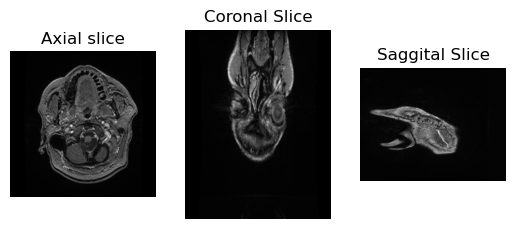

In [233]:
plt.close('all')

#####         AXIAL         #####
plt.subplot(131)
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')

#####    CORONAL    #####
plt.subplot(132)
plt.imshow(coronal_slice, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')

#####    SAGITTAL    #####
plt.subplot(133)
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')

plt.show()

In [234]:
vol_py = get_vol_data_pydicom(3)


Skipping file: MR.1.2.246.352.221.55961979136446000507635034711674195903.dcm
DS Type: RT Structure Set Storage
Found 332 slices


In [235]:
index = 50
axial_slice = directional_slices(vol_py, index, 'axial')
saggital_slice = directional_slices(vol_py, index, 'saggital')
coronal_slice = directional_slices(vol_py, index, 'coronal')

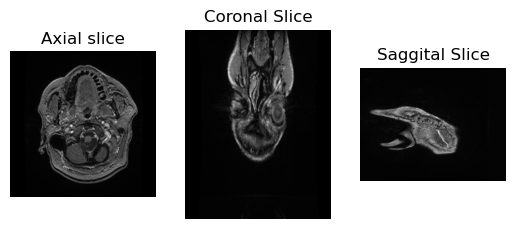

In [236]:
plt.close('all')

#####         AXIAL         #####
plt.subplot(131)
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial slice')
plt.axis('off')

#####    CORONAL    #####
plt.subplot(132)
plt.imshow(coronal_slice, cmap='gray') # print pixel data of dicom file
plt.title('Coronal Slice')
plt.axis('off')

#####    SAGITTAL    #####
plt.subplot(133)
plt.imshow(saggital_slice.T, cmap='gray') # print pixel data of dicom file
plt.title('Saggital Slice')
plt.axis('off')

plt.show()